In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import preprocess_input

In [3]:
# ======================
# Load trained model
# ======================

model = tf.keras.models.load_model("/content/drive/MyDrive/pneumonia/ppneumonia_resnet50_final.h5")

In [4]:
# ======================
# Predict function
# ======================

def predict_pneumonia(image_path):

    # Read image
    img = cv2.imread(image_path)

    # Resize to ResNet size
    img_resized = cv2.resize(img, (224,224))

    # Preprocess for ResNet
    img_preprocessed = preprocess_input(img_resized)

    # Add batch dimension
    img_input = np.expand_dims(img_preprocessed, axis=0)

    # Predict
    prediction = model.predict(img_input)[0][0]

    # Result
    if prediction > 0.5:
        result = "PNEUMONIA DETECTED"
        confidence = prediction
    else:
        result = "NORMAL"
        confidence = 1 - prediction

    # Show image
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"{result}\nConfidence: {confidence:.2f}")
    plt.axis("off")
    plt.show()

    print("Prediction Value:", prediction)
    print("Result:", result)
    print("Confidence:", confidence)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


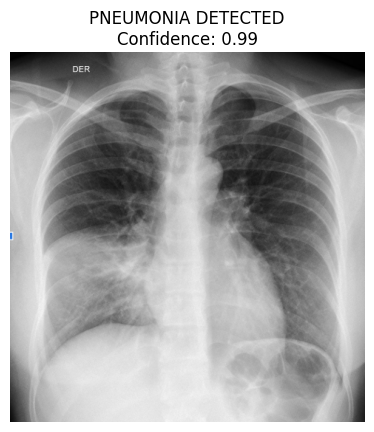

Prediction Value: 0.9899122
Result: PNEUMONIA DETECTED
Confidence: 0.9899122


In [10]:
# ======================
# Test with unknown image
# ======================

predict_pneumonia("/content/drive/MyDrive/pneumonia/test_data/pne_image345.png")